In [ ]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import random

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import common

    reload(common)


from common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_dist,
    calc_rectangle_area,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_sorted_edges,
    kruskals_algorithm,
    my_deepcopy,
    prim,
    prim_k,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

<!-- やること

- 初期解を生成する

  - グループを 2 つ選ぶ
    - グループを 1 つ選ぶ

- 以下を持つオブジェクト
  - ソート済み辺(cost, a, b)
  - 対象頂点 set
  - 現在のエッジ
  - 正解のエッジ
  - 現在の誤りエッジ数
  - V = len(頂点 set)
  - 辺の更新(input: ソート済み更新辺)
    - 更新辺に含まれているエッジがあれば削除
    - 元の辺と、更新辺を前から捜査していき、小さい順に追加する
    - クラスカル法で現在のエッジを更新
    - V - 正解エッジ数を算出

全辺の総数 = (env.L - 1) / env.Q

- 1 点を更新する
  - cost = 0
  - 1 つの全域木 INFO for 全全域木 INFO
    - その全域木内の点が更新対象でないな
      - cost += 誤りエッジ数
    - 更新対象である
      - 更新点と、全域木内の点の距離を計算してエッジを作成
      - エッジをソート
      - 辺の更新メソッドを呼ぶ
      - cost += 誤りエッジ数
  - total_cost = cost / 全辺の総数 -->


In [47]:
# =================================
# 以下メイン処理
# =================================
class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = {v: [] for v in self.vs}
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


class MSTInfo:
    def __init__(self, correct_edges: list, vs: list, sorted_edges: list):
        self.set_correct_edges = correct_edges
        self.vs = vs
        self.vs_set = set(vs)

        self.edge_num = len(correct_edges)

        self._next_edges = None
        self._next_cost = None

        self._now_sorted_edges = sorted_edges
        self._now_cost = self._calc_cost(self._now_sorted_edges)

    def temp_update(self, ex_edges):
        self._next_edges = self._get_ex_edges(ex_edges)
        self._next_cost = self._calc_cost(self._next_edges)

    def accept(self):
        if self._next_edges is not None:
            self._now_sorted_edges = self._next_edges
            self._next_edges = None

            self._now_cost = self._next_cost
            self._next_cost = None

    def reject(self):
        self._next_cost = None
        self._next_edges = None

    def cost(self):
        if self._next_cost is not None:
            return self._next_cost
        return self._now_cost

    def _calc_cost(self, target_edges):
        mistakes = 0
        uf = UnionFind(self.vs)
        for edge in target_edges:
            _, a, b = edge
            if not uf.same(a, b):
                uf.union(a, b)
                if (a, b) not in self.set_correct_edges:
                    mistakes += 1
        return mistakes

    def _get_ex_edges(self, ex_edges):
        edge_vs = set()
        for e in ex_edges:
            edge_vs.add((e[1], e[2]))

        new_edges = []
        for e in self._now_sorted_edges:
            if (e[1], e[2]) in edge_vs:
                continue
            new_edges.append(e)

        ret_edges = []
        i, j = 0, 0
        N, M = len(new_edges), len(ex_edges)
        while i < N and j < M:
            if new_edges[i][0] < ex_edges[j][0]:
                ret_edges.append(new_edges[i])
                i += 1
            else:
                ret_edges.append(ex_edges[j])
                j += 1

        return ret_edges


def define_query_cnt(env: Env, limit_query_cnt=LIMIT_QUERY_CNT):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= env.G[g]:
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < env.G[g]:
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / env.G[g]
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1
            if limit_query_cnt is not None and min_cost >= limit_query_cnt:
                break
    return group_query_cnt


def update_mst(
    env: Env,
    ans_v,
    ans_edges,
    group_query_cnt: dict[int, int],
):
    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
        elif 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
        else:
            my_graph = MyGraph(now_v, now_edges, g)
            for _ in range(group_query_cnt[g]):
                rand_v = my_graph.choice_min_visited()
                visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
                new_edges = env.query(visited_v)
                my_graph.update_edges(visited_edge, new_edges)
            ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


def select_neighbor_rectangle_k(
    rectangles: list[list[int]],
    init_v: int,
    k: int,
    used_v: set[int],
    N: int,
):
    # 選んだ四角形の存在領域が大きくならないように選択を繰り返す O(N^2)
    used = used_v | {init_v}
    not_used = set(range(N)) - used

    ans_v = [init_v]
    now_rects = rectangles[init_v]
    while len(ans_v) < k:
        min_area = float("inf")
        min_v = None
        min_rects = None
        for v in not_used:
            nl, nr, nt, nb = now_rects
            l, r, t, b = rectangles[v]
            tl, tr, tt, tb = min(nl, l), max(nr, r), min(nt, t), max(nb, b)
            area = calc_rectangle_area((tl, tr, tt, tb))
            if area < min_area:
                min_area = area
                min_v = v
                min_rects = tl, tr, tt, tb
        if min_v is None:
            debug_print("ERROR: min_v is None")
            break
        ans_v.append(min_v)
        not_used.remove(min_v)
        used.add(min_v)
        now_rects = min_rects
    return ans_v


def calc_greedy_answer(env: Env, target_points):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)
        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges


def _select_min_area(rectangles, not_used):
    min_area = float("inf")
    min_v = None
    for v in not_used:
        area = calc_rectangle_area(rectangles[v])
        if area < min_area:
            min_area = area
            min_v = v
    return min_v


def calc_greedy_answer_from_rectangle(env: Env):
    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = _select_min_area(env.rectangles, not_used)
        prim_v = select_neighbor_rectangle_k(env.rectangles, v, group_size, now_used, env.N)
        graph = construct_graph({v: env.cneter_points[v] for v in prim_v})
        prim_edges, _ = prim(graph)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges

In [48]:
file_num = 62
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [49]:
anv_v_correct, ans_edges_correct = calc_greedy_answer(env, env.coordinates)

# anv_v_estimate, ans_edges_estimate = calc_greedy_answer_from_rectangle(env)
anv_v_estimate, ans_edges_estimate = calc_greedy_answer(env, env.cneter_points)
ans_v_update, ans_edges_update = update_mst(
    env,
    my_deepcopy(anv_v_estimate),
    my_deepcopy(ans_edges_estimate),
    define_query_cnt(env),
)


In [50]:
import numpy as np

corrects = np.array(env.coordinates)
centers = np.array(env.cneter_points)
print("best", env.answer(anv_v_correct, ans_edges_correct))
print("estimate", env.answer(anv_v_estimate, ans_edges_estimate))
print("update", env.answer(ans_v_update, ans_edges_update))

query: 400
best 189537.0
query: 400
estimate 463578.0
query: 400
update 267682.0


In [51]:
print(env.L, env.M, env.W)
print(env.G)

14 79 2072
[12, 1, 25, 1, 10, 3, 7, 10, 12, 12, 11, 7, 28, 3, 4, 15, 2, 19, 24, 15, 3, 1, 24, 7, 13, 2, 6, 8, 6, 5, 6, 18, 6, 5, 26, 21, 7, 8, 1, 8, 38, 28, 23, 5, 14, 4, 9, 11, 1, 13, 8, 4, 17, 17, 3, 9, 27, 20, 10, 19, 3, 2, 8, 7, 13, 2, 9, 6, 10, 8, 18, 2, 4, 6, 1, 5, 3, 8, 3]


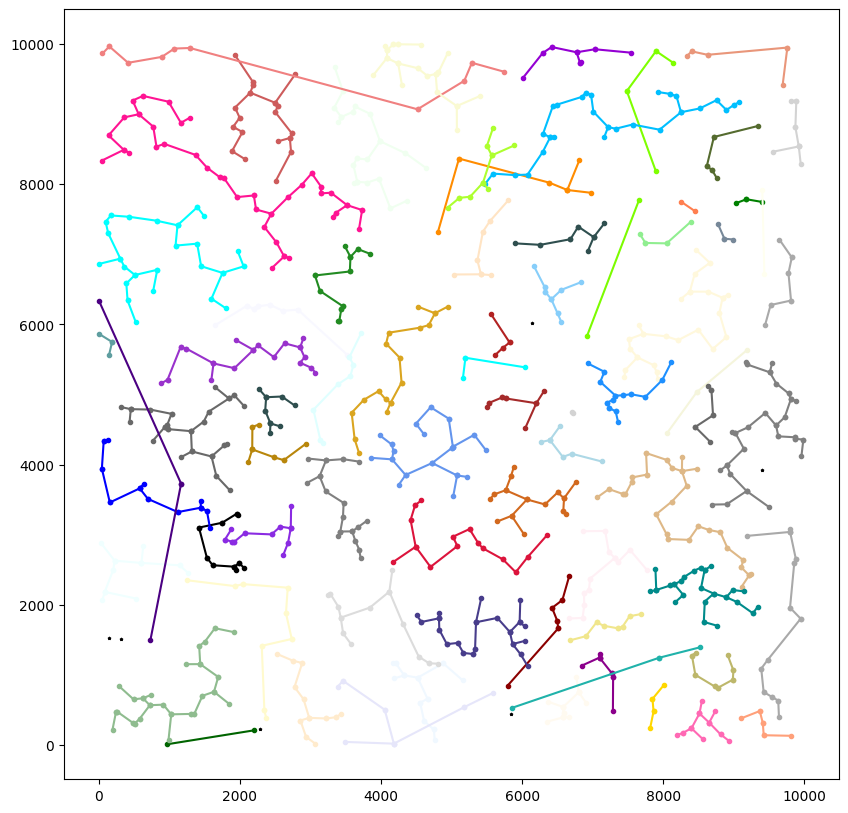

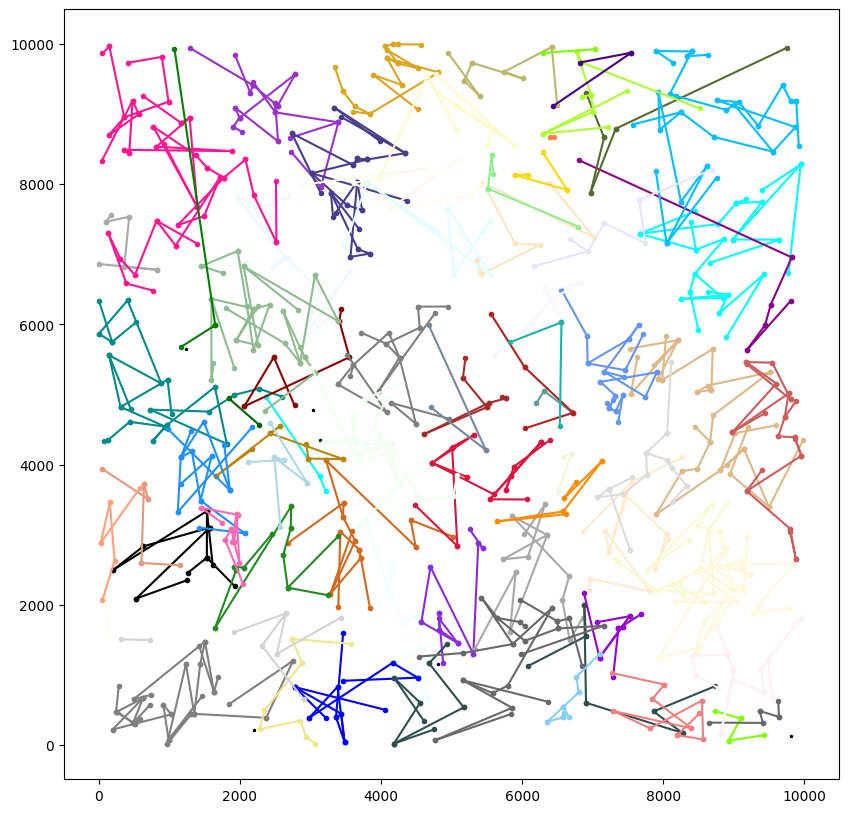

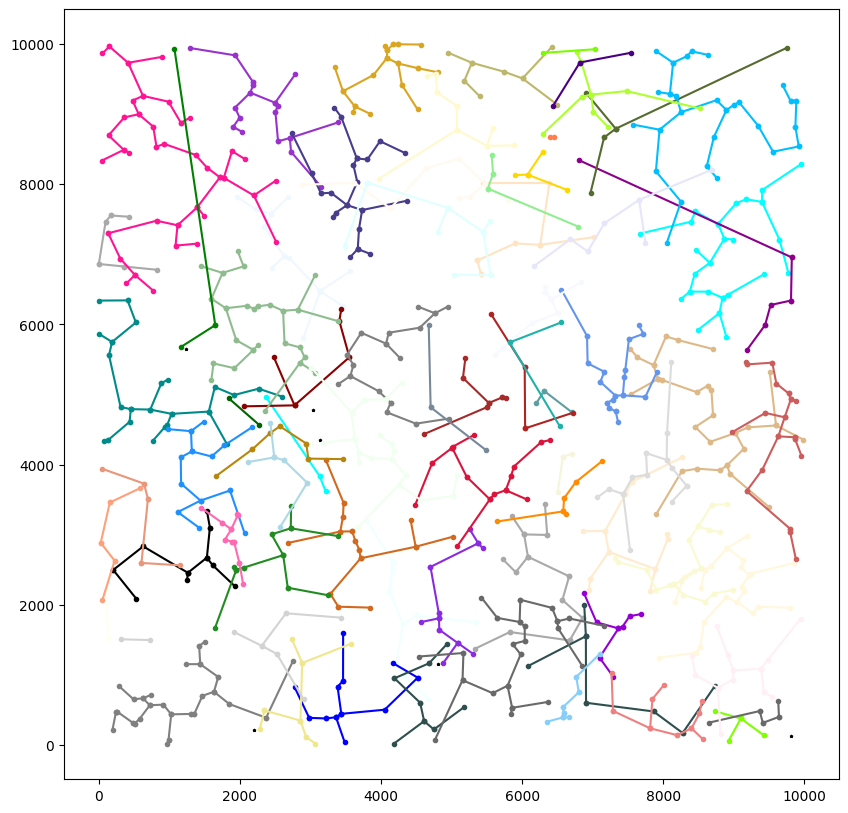

In [52]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# def get_color(i):
#     colors = plt.get_cmap("tab30").colors
#     return colors[i % len(colors)]


def get_color(i):
    colors = list(matplotlib.colors.CSS4_COLORS.values())
    return colors[i % len(colors)]


def draw_answer(ans_v, ans_edges):
    correct_coords = np.array(env.coordinates)
    plt.figure(figsize=(10, 10))

    for g, (vs, edges) in enumerate(zip(ans_v, ans_edges)):
        if len(vs) == 1:
            coord = correct_coords[vs][0]
            plt.scatter(coord[0], coord[1], color="black", marker="*", s=3)
        vs = np.array(vs)
        edges = np.array(edges)
        for e in edges:
            cs = correct_coords[e]
            plt.plot(
                cs[:, 0],
                cs[:, 1],
                color=get_color(g),
                marker="o",
                markersize=3,
            )
    plt.show()


draw_answer(anv_v_correct, ans_edges_correct)
draw_answer(anv_v_estimate, ans_edges_estimate)
draw_answer(ans_v_update, ans_edges_update)

In [53]:
# point_inds = list(range(env.N))  # longs_points[:]
# corrects_np = np.array(corrects)[point_inds]
# estimates_np = np.array(estimates)[point_inds]
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# # 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
# # for i, rect in enumerate(rectangles):
# #     l, r, t, b = rect
# #     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
# ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
# ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
# for point_ind in range(len(corrects_np)):
#     ax.plot(
#         (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
#         (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
#         color="gray",
#         label="correct path",
#     )
# plt.show()